# 05 · Modelo Early Fusion (mejor modelo)

**Objetivo:** Combinar imágenes y metadatos clínicos en un único modelo que aprenda las interacciones entre ambas modalidades de forma conjunta.

**Datos de entrada:** `../data/raw/hnmist_28_28_RGB.csv`, `../data/raw/HAM10000_metadata.csv`

**Resultado esperado:** Modelo guardado en `../models/mejor_modelo_early_fusion.keras` con ~80% de accuracy en test.

**Arquitectura:** Functional API con dos ramas (CNN + Dense) concatenadas antes de la capa de salida.

**Por qué Early Fusion supera a los modelos individuales:** al concatenar las representaciones de imagen y tabular antes de la clasificación final, el modelo puede aprender interacciones entre ambas fuentes (ej. una lesión pigmentada en la espalda de un hombre mayor tiene un perfil de riesgo diferente a la misma lesión en otra localización).

# Modelo 3D: Early Fusion
Ahora, vamos a utilizar la estrategia Early fusion para crear un modelo que combina los datos tabulares (el primer modelo que hicimos) con las imágenes para que el modelo tenga en cuenta además de los datos de imágenes, factores como en qué parte del cuerpo está la lesión, el sexo del paciente y su edad. En este caso, no tendríamos que importar todas las librerías que cargábamos antes, ya que vamos a reutilizar los modelos 1D y 2D 

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ── Carga y preprocesado centralizados en utils.py ────────────────────────────
from utils import get_all_splits

(X_img_train, X_img_val, X_img_test,
 X_tab_train, X_tab_val, X_tab_test,
 y_train, y_val, y_test, le) = get_all_splits()

num_classes = y_train.shape[1]
n_tab_features = X_tab_train.shape[1]

# ── Pesos de clase para compensar el desbalanceo ──────────────────────────────
y_train_labels = np.argmax(y_train, axis=1)
weights = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight = dict(enumerate(weights))
print("Pesos por clase:")
for k, v in class_weight.items():
    print(f"  {le.classes_[k]:6s}: {v:.2f}")

# ── Arquitectura Early Fusion ─────────────────────────────────────────────────
input_img = Input(shape=(28, 28, 3), name="input_img")
x = Conv2D(32,  (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64,  (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)

input_tab = Input(shape=(n_tab_features,), name="input_tab")
t = Dense(32, activation='relu')(input_tab)
t = Dense(32, activation='relu')(t)

combined = Concatenate()([x, t])
z = Dropout(0.5)(combined)
output = Dense(num_classes, activation='softmax')(z)

early_fusion_model = Model(inputs=[input_img, input_tab], outputs=output)
early_fusion_model.compile(optimizer=Adam(0.001),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])
early_fusion_model.summary()

# ── Entrenamiento ─────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, min_delta=0.005, restore_best_weights=True)

history = early_fusion_model.fit(
    [X_img_train, X_tab_train], y_train,
    validation_data=([X_img_val, X_tab_val], y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight
)

# ── Evaluación ────────────────────────────────────────────────────────────────
test_loss, test_acc = early_fusion_model.evaluate([X_img_test, X_tab_test], y_test)
print(f"Test accuracy: {test_acc:.4f}")

os.makedirs('../models', exist_ok=True)
early_fusion_model.save('../models/mejor_modelo_early_fusion.keras')
print("Modelo guardado en ../models/mejor_modelo_early_fusion.keras")

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy — Early Fusion')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

## Evaluación detallada por clase

El accuracy global no es suficiente en diagnóstico médico. Aquí vemos cuánto acierta el modelo en **cada tipo de lesión** por separado, y lo comparamos con el **baseline ZeroR** (lo que conseguiría un modelo que predice siempre la clase más frecuente, sin aprender nada).

In [3]:
from sklearn.metrics import classification_report
import numpy as np

# Predicciones sobre el conjunto de test
y_pred_probs = early_fusion_model.predict([X_img_test, X_tab_test])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Baseline ZeroR: accuracy de predecir siempre la clase más frecuente
from collections import Counter
most_common = Counter(y_true).most_common(1)[0][1]
baseline = most_common / len(y_true)
print(f'Baseline ZeroR (predecir siempre la clase más frecuente): {baseline:.2%}')
print(f'Accuracy del modelo: {(y_pred == y_true).mean():.2%}')
print(f'Mejora sobre baseline: {(y_pred == y_true).mean() - baseline:+.2%}')

# Desglose por clase
print('Resultados por clase diagnóstica:')
print(classification_report(y_true, y_pred, target_names=le.classes_))

47/47 [==============================] - 1s 7ms/step
Baseline ZeroR (predecir siempre la clase más frecuente): 66.93%
Accuracy del modelo: 78.44%
Mejora sobre baseline: +11.51%
Resultados por clase diagnóstica:
              precision    recall  f1-score   support

       akiec       0.50      0.39      0.44        49
         bcc       0.48      0.68      0.56        77
         bkl       0.52      0.46      0.49       165
          df       0.50      0.06      0.11        17
         mel       0.59      0.43      0.50       167
          nv       0.88      0.94      0.91      1006
        vasc       1.00      0.41      0.58        22

    accuracy                           0.78      1503
   macro avg       0.64      0.48      0.51      1503
weighted avg       0.77      0.78      0.77      1503



## Curvas ROC y matriz de confusión

La **curva ROC** mide cómo de bien el modelo separa cada clase del resto. El **AUC** (área bajo la curva) resume esto en un número: 1.0 = perfecto, 0.5 = aleatorio (no aprende nada).

En diagnóstico médico el AUC del **melanoma** (`mel`) es especialmente crítico: un falso negativo (diagnosticar como benigno algo maligno) tiene consecuencias graves.

La **matriz de confusión** muestra dónde se equivoca el modelo: qué clases confunde entre sí.

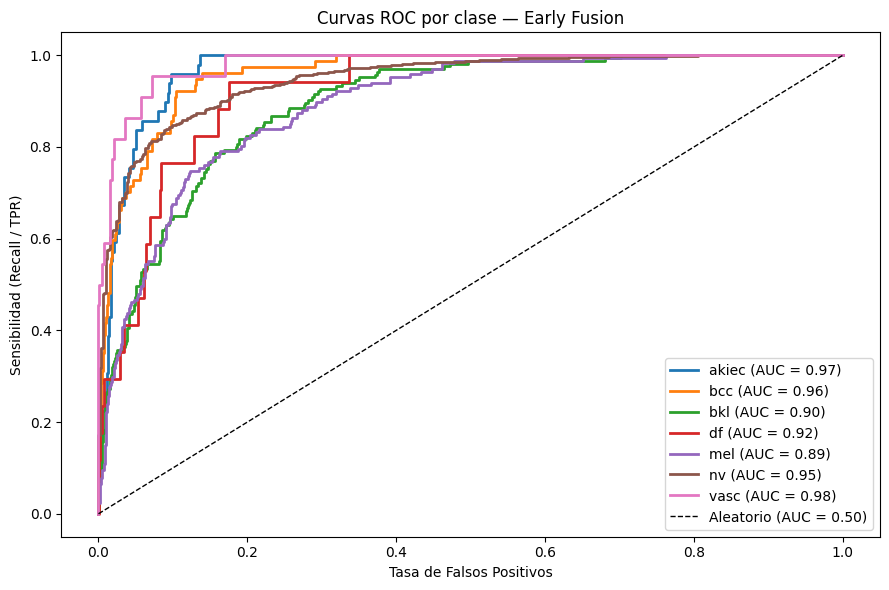

AUC macro (promedio One-vs-Rest): 0.9386


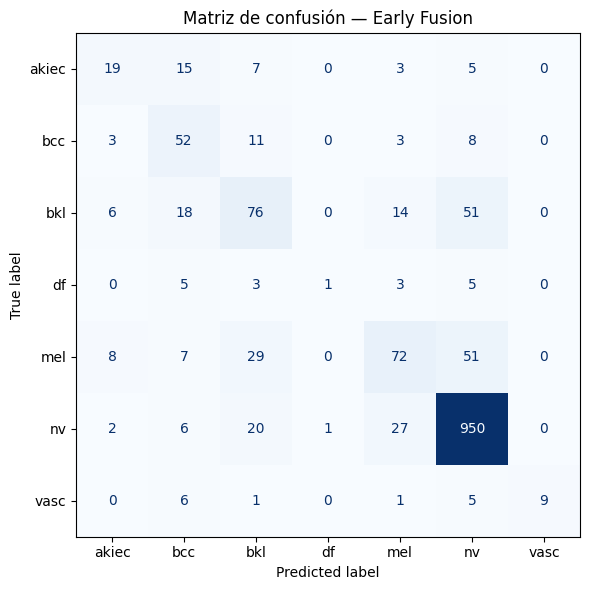

In [4]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# ── Curvas ROC por clase ──────────────────────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=range(len(le.classes_)))

fig, ax = plt.subplots(figsize=(9, 6))
for i, (clase, color) in enumerate(zip(le.classes_, plt.cm.tab10.colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{clase} (AUC = {auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.50)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Sensibilidad (Recall / TPR)')
ax.set_title('Curvas ROC por clase — Early Fusion')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr', average='macro')
print(f'AUC macro (promedio One-vs-Rest): {macro_auc:.4f}')

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Early Fusion')
plt.tight_layout()
plt.show()

# Modelo 3: Conclusiones 
En nuestro modelo 3 (Early fusion) Como vemos en la gráfica más arriba, el valor de accuracy ha estado aumentando durante todo el entrenamiento, lo cual nos deja conclusiones muy positivas para este modelo, ya que hemos llegado a alcanzar un 80% (valor más alto hasta ahora)
El modelo aprende de manera estable, y detiene su entrenamiento en epoch 23, el cual sería el punto donde detener el aprendizaje. 
Como vemos, combinar los datos tabulares con los resultados de la CNN ha conseguido que tengamos unas predicciones más fiables. Esto también nos indica que los datos tabualres pueden resultar de ayuda 
